# Sales Forecasting — Baseline+
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (improved baseline):**
1. Build a recency-weighted seasonal profile by **(month, day)**.
2. Estimate YoY growth and calibrate damping on a validation tail (2021–2022).
3. Add weekday + promotion/holiday/Tet residual adjustments.
4. Backtest quickly, then export submission.

## 1 — Imports & Config

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('.')
TRAIN_FILE = DATA_DIR / 'analytical' / 'sales.csv'
TEST_FILE = DATA_DIR / 'analytical' / 'sample_submission.csv'
PROMO_FILE = DATA_DIR / 'master' / 'promotions.csv'

OUT_DIR = Path('../data_cleaned/forecast')
OUT_FILE = OUT_DIR / 'baseline_plus_submission.csv'
OUT_FILE_CANONICAL = OUT_DIR / 'submission.csv'

## 2 — Load & Inspect Data

In [12]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date']).sort_values('Date').reset_index(drop=True)

if PROMO_FILE.exists():
    promo = pd.read_csv(PROMO_FILE, parse_dates=['start_date', 'end_date'])
else:
    promo = pd.DataFrame(columns=['start_date', 'end_date', 'discount_value'])

if 'discount_value' not in promo.columns:
    promo['discount_value'] = 0.0
promo['discount_value'] = promo['discount_value'].fillna(0.0).astype(float)

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print('Promo rows:', len(promo))
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01
Promo rows: 50



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


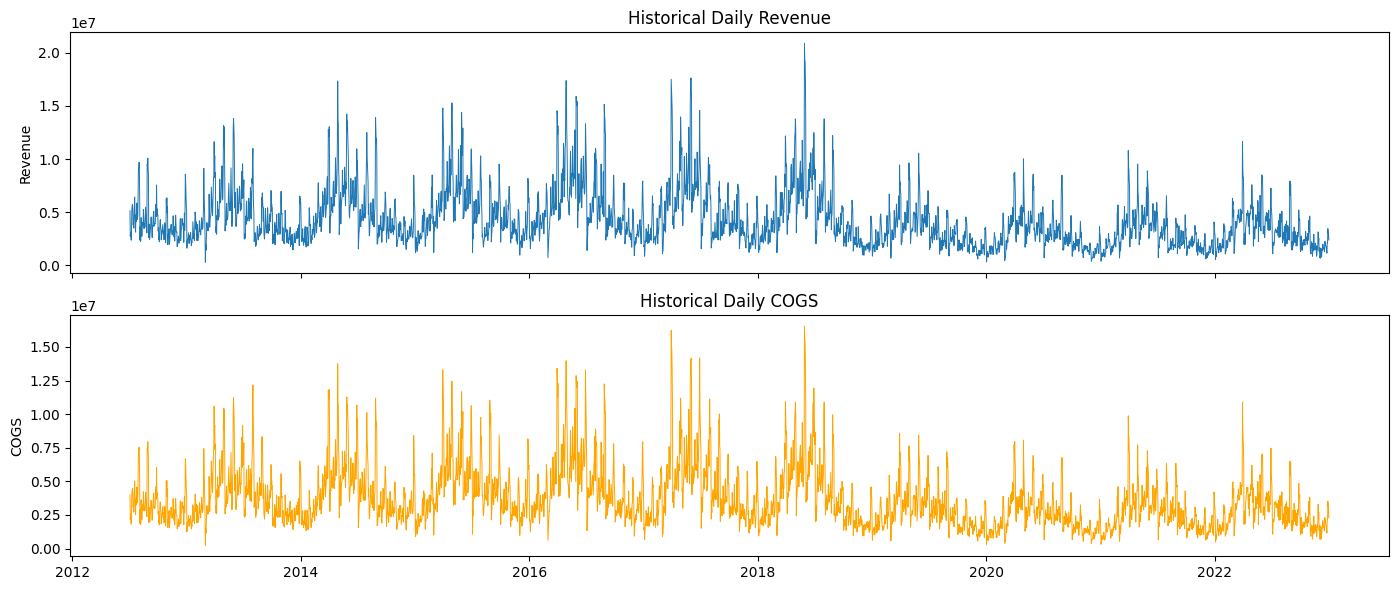

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [14]:
for df in (train, test):
    df['year']    = df['Date'].dt.year
    df['month']   = df['Date'].dt.month
    df['day']     = df['Date'].dt.day
    df['weekday'] = df['Date'].dt.weekday

# Annual totals for trend estimation
annual = train.groupby('year')[['Revenue', 'COGS']].sum()

# Annual means to normalize within year
annual_means = (
    train.groupby('year')[['Revenue', 'COGS']]
    .mean()
    .rename(columns={'Revenue': 'annual_rev_mean', 'COGS': 'annual_cogs_mean'})
)
train = train.merge(annual_means, left_on='year', right_index=True, how='left')

print('Annual totals:')
print(annual)

Annual totals:
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [15]:
# --- Raw YoY growth (geometric mean, 2013–2022) ---
full_years = annual.loc[2013:2022].copy()

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

raw_growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
raw_growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Raw geometric YoY Revenue growth : {raw_growth_rev:.4f}  ({(raw_growth_rev-1)*100:.2f}%/yr)')
print(f'Raw geometric YoY COGS    growth : {raw_growth_cogs:.4f}  ({(raw_growth_cogs-1)*100:.2f}%/yr)')

Raw geometric YoY Revenue growth : 0.9620  (-3.80%/yr)
Raw geometric YoY COGS    growth : 0.9605  (-3.95%/yr)


## 4 — Build Recency-Weighted Seasonal + Weekday Profiles

Use normalized values and higher weight for recent years to reduce old-pattern bias.

In [16]:
train['year_weight'] = (train['year'] - train['year'].min() + 1).astype(float)

train['rev_norm'] = train['Revenue'] / train['annual_rev_mean'].replace(0, np.nan)
train['cogs_norm'] = train['COGS'] / train['annual_cogs_mean'].replace(0, np.nan)
train['rev_norm'] = train['rev_norm'].replace([np.inf, -np.inf], np.nan).fillna(1.0)
train['cogs_norm'] = train['cogs_norm'].replace([np.inf, -np.inf], np.nan).fillna(1.0)

def wavg(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if np.sum(weights) <= 0:
        return float(np.mean(values))
    return float(np.average(values, weights=weights))

seasonal = (
    train.groupby(['month', 'day'])
    .apply(lambda g: pd.Series({
        'rev_norm': wavg(g['rev_norm'], g['year_weight']),
        'cogs_norm': wavg(g['cogs_norm'], g['year_weight']),
    }))
    .reset_index()
)

train_season = train.merge(seasonal, on=['month', 'day'], how='left', suffixes=('', '_season'))
train_season['rev_resid'] = train_season['Revenue'] / (train_season['annual_rev_mean'] * train_season['rev_norm_season']).replace(0, np.nan)
train_season['cogs_resid'] = train_season['COGS'] / (train_season['annual_cogs_mean'] * train_season['cogs_norm_season']).replace(0, np.nan)

weekday_profile = (
    train_season.groupby('weekday')[['rev_resid', 'cogs_resid']]
    .median()
    .rename(columns={'rev_resid': 'rev_wday_factor', 'cogs_resid': 'cogs_wday_factor'})
    .reset_index()
)
weekday_profile['rev_wday_factor'] = weekday_profile['rev_wday_factor'].fillna(1.0).clip(0.85, 1.15)
weekday_profile['cogs_wday_factor'] = weekday_profile['cogs_wday_factor'].fillna(1.0).clip(0.85, 1.15)

print('Seasonal profile rows:', len(seasonal))
print('Weekday profile rows:', len(weekday_profile))
display(seasonal.head(10))
display(weekday_profile)

Seasonal profile rows: 366
Weekday profile rows: 7


,month,day,rev_norm,cogs_norm
0,1,1,0.801819,0.892686
1,1,2,0.400083,0.413737
2,1,3,0.292226,0.273023
3,1,4,0.346435,0.317989
4,1,5,0.383339,0.352024
5,1,6,0.396382,0.367514
6,1,7,0.404590,0.380558
7,1,8,0.457094,0.426858
8,1,9,0.478655,0.454329
9,1,10,0.517271,0.480715


,weekday,rev_wday_factor,cogs_wday_factor
0,0,1.031772,1.026682
1,1,1.040853,1.036052
2,2,1.062912,1.059007
3,3,1.037391,1.037858
4,4,0.918557,0.921414
5,5,0.914254,0.909829
6,6,0.954258,0.957094


## 5 — Predict Test Period (Calibrated Baseline+)

Calibrate growth damping on 2021–2022, then apply weekday and event adjustments.

In [17]:
base_year = 2022 if 2022 in annual.index else int(annual.index.max())
base_rev = annual.loc[base_year, 'Revenue'] / 365.0
base_cogs = annual.loc[base_year, 'COGS'] / 365.0

seasonal_model = seasonal.rename(columns={'rev_norm': 'rev_norm_season', 'cogs_norm': 'cogs_norm_season'})

cal = train.merge(seasonal_model, on=['month', 'day'], how='left').merge(weekday_profile, on='weekday', how='left')
cal['rev_norm'] = cal['rev_norm_season'].fillna(1.0)
cal['cogs_norm'] = cal['cogs_norm_season'].fillna(1.0)
cal['rev_wday_factor'] = cal['rev_wday_factor'].fillna(1.0)
cal['cogs_wday_factor'] = cal['cogs_wday_factor'].fillna(1.0)

cal['years_ahead'] = cal['year'] - base_year
val_mask = cal['year'].isin([2021, 2022])
cal_val = cal.loc[val_mask].copy()

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

candidate_lam = np.linspace(0.0, 1.0, 11)
best_lam_rev, best_lam_cogs = 1.0, 1.0
best_mape_rev, best_mape_cogs = np.inf, np.inf

for lam in candidate_lam:
    g_rev = 1.0 + lam * (raw_growth_rev - 1.0)
    rev_pred = base_rev * (g_rev ** cal_val['years_ahead']) * cal_val['rev_norm'] * cal_val['rev_wday_factor']
    rev_score = mape(cal_val['Revenue'], rev_pred)
    if rev_score < best_mape_rev:
        best_mape_rev = rev_score
        best_lam_rev = float(lam)

for lam in candidate_lam:
    g_cogs = 1.0 + lam * (raw_growth_cogs - 1.0)
    cogs_pred = base_cogs * (g_cogs ** cal_val['years_ahead']) * cal_val['cogs_norm'] * cal_val['cogs_wday_factor']
    cogs_score = mape(cal_val['COGS'], cogs_pred)
    if cogs_score < best_mape_cogs:
        best_mape_cogs = cogs_score
        best_lam_cogs = float(lam)

growth_rev = 1.0 + best_lam_rev * (raw_growth_rev - 1.0)
growth_cogs = 1.0 + best_lam_cogs * (raw_growth_cogs - 1.0)

# Build base predictions on train for residual event learning
cal['Revenue_pred_legacy'] = (base_rev * (raw_growth_rev ** cal['years_ahead']) * cal['rev_norm']).clip(lower=0)
cal['COGS_pred_legacy'] = (base_cogs * (raw_growth_cogs ** cal['years_ahead']) * cal['cogs_norm']).clip(lower=0)

cal_base_rev = (base_rev * (growth_rev ** cal['years_ahead']) * cal['rev_norm'] * cal['rev_wday_factor']).clip(lower=0)
cal_base_cogs = (base_cogs * (growth_cogs ** cal['years_ahead']) * cal['cogs_norm'] * cal['cogs_wday_factor']).clip(lower=0)

# Build test matrix
model_test = test.merge(seasonal_model, on=['month', 'day'], how='left').merge(weekday_profile, on='weekday', how='left')
model_test['rev_norm'] = model_test['rev_norm_season'].fillna(1.0)
model_test['cogs_norm'] = model_test['cogs_norm_season'].fillna(1.0)
model_test['rev_wday_factor'] = model_test['rev_wday_factor'].fillna(1.0)
model_test['cogs_wday_factor'] = model_test['cogs_wday_factor'].fillna(1.0)
model_test['years_ahead'] = model_test['year'] - base_year

def build_promo_daily(promo_df):
    if promo_df.empty:
        return pd.DataFrame(columns=['Date', 'promo_count', 'avg_discount'])

    chunks = []
    for _, r in promo_df.iterrows():
        start = r.get('start_date')
        end = r.get('end_date')
        if pd.isna(start) or pd.isna(end) or end < start:
            continue
        days = pd.date_range(start, end, freq='D')
        chunks.append(pd.DataFrame({
            'Date': days,
            'promo_count': 1.0,
            'discount_value': float(r.get('discount_value', 0.0) or 0.0),
        }))

    if not chunks:
        return pd.DataFrame(columns=['Date', 'promo_count', 'avg_discount'])

    return (
        pd.concat(chunks, ignore_index=True)
        .groupby('Date', as_index=False)
        .agg(promo_count=('promo_count', 'sum'), avg_discount=('discount_value', 'mean'))
    )

promo_daily = build_promo_daily(promo)

TET_DATE = {
    2013: pd.Timestamp('2013-02-10'),
    2014: pd.Timestamp('2014-01-31'),
    2015: pd.Timestamp('2015-02-19'),
    2016: pd.Timestamp('2016-02-08'),
    2017: pd.Timestamp('2017-01-28'),
    2018: pd.Timestamp('2018-02-16'),
    2019: pd.Timestamp('2019-02-05'),
    2020: pd.Timestamp('2020-01-25'),
    2021: pd.Timestamp('2021-02-12'),
    2022: pd.Timestamp('2022-02-01'),
    2023: pd.Timestamp('2023-01-22'),
    2024: pd.Timestamp('2024-02-10'),
}
fixed_holidays = {(1, 1), (4, 30), (5, 1), (9, 2), (12, 24), (12, 25), (12, 31)}

def is_tet_period(ts, pre_days=10, post_days=7):
    tet = TET_DATE.get(ts.year)
    if tet is None:
        return False
    return (tet - pd.Timedelta(days=pre_days)) <= ts <= (tet + pd.Timedelta(days=post_days))

def add_event_features(df):
    out = df.merge(promo_daily, on='Date', how='left')
    out['promo_count'] = out['promo_count'].fillna(0.0)
    out['avg_discount'] = out['avg_discount'].fillna(0.0)
    out['is_holiday'] = out['Date'].apply(lambda x: (x.month, x.day) in fixed_holidays)
    out['is_tet'] = out['Date'].apply(is_tet_period)
    return out

cal = add_event_features(cal)
model_test = add_event_features(model_test)

cal['rev_ratio'] = cal['Revenue'] / cal_base_rev.replace(0, np.nan)
cal['cogs_ratio'] = cal['COGS'] / cal_base_cogs.replace(0, np.nan)

global_rev_med = cal['rev_ratio'].dropna().median()
global_cogs_med = cal['cogs_ratio'].dropna().median()
if not np.isfinite(global_rev_med) or global_rev_med <= 0:
    global_rev_med = 1.0
if not np.isfinite(global_cogs_med) or global_cogs_med <= 0:
    global_cogs_med = 1.0

def median_ratio(series, mask, global_med):
    vals = series.loc[mask].dropna()
    if len(vals) == 0:
        return 1.0
    return float(np.clip(vals.median() / global_med, 0.7, 1.5))

promo_rev_mult = median_ratio(cal['rev_ratio'], cal['promo_count'] > 0, global_rev_med)
promo_cogs_mult = median_ratio(cal['cogs_ratio'], cal['promo_count'] > 0, global_cogs_med)
holiday_rev_mult = median_ratio(cal['rev_ratio'], cal['is_holiday'], global_rev_med)
holiday_cogs_mult = median_ratio(cal['cogs_ratio'], cal['is_holiday'], global_cogs_med)
tet_rev_mult = median_ratio(cal['rev_ratio'], cal['is_tet'], global_rev_med)
tet_cogs_mult = median_ratio(cal['cogs_ratio'], cal['is_tet'], global_cogs_med)

tmp_rev = cal.loc[cal['avg_discount'] > 0, ['rev_ratio', 'avg_discount']].dropna()
if len(tmp_rev):
    rev_discount_coef = ((tmp_rev['rev_ratio'] / global_rev_med - 1.0) / tmp_rev['avg_discount']).median()
else:
    rev_discount_coef = 0.0
rev_discount_coef = float(np.clip(rev_discount_coef, -0.5, 0.5))

tmp_cogs = cal.loc[cal['avg_discount'] > 0, ['cogs_ratio', 'avg_discount']].dropna()
if len(tmp_cogs):
    cogs_discount_coef = ((tmp_cogs['cogs_ratio'] / global_cogs_med - 1.0) / tmp_cogs['avg_discount']).median()
else:
    cogs_discount_coef = 0.0
cogs_discount_coef = float(np.clip(cogs_discount_coef, -0.5, 0.5))

def event_multiplier(df, promo_mult, holiday_mult, tet_mult, discount_coef):
    mult = np.ones(len(df), dtype=float)
    mult *= np.where(df['promo_count'] > 0, promo_mult, 1.0)
    mult *= np.where(df['is_holiday'], holiday_mult, 1.0)
    mult *= np.where(df['is_tet'], tet_mult, 1.0)
    mult *= (1.0 + discount_coef * df['avg_discount'])
    return np.clip(mult, 0.7, 1.6)

# Final train predictions (for validation table)
cal_rev_event = event_multiplier(cal, promo_rev_mult, holiday_rev_mult, tet_rev_mult, rev_discount_coef)
cal_cogs_event = event_multiplier(cal, promo_cogs_mult, holiday_cogs_mult, tet_cogs_mult, cogs_discount_coef)
cal['Revenue_pred_improved'] = (cal_base_rev * cal_rev_event).clip(lower=0)
cal['COGS_pred_improved'] = (cal_base_cogs * cal_cogs_event).clip(lower=0)
cal['COGS_pred_improved'] = np.minimum(cal['COGS_pred_improved'], cal['Revenue_pred_improved'] * 0.995)

# Final test predictions
test_base_rev = base_rev * (growth_rev ** model_test['years_ahead']) * model_test['rev_norm'] * model_test['rev_wday_factor']
test_base_cogs = base_cogs * (growth_cogs ** model_test['years_ahead']) * model_test['cogs_norm'] * model_test['cogs_wday_factor']

test_rev_event = event_multiplier(model_test, promo_rev_mult, holiday_rev_mult, tet_rev_mult, rev_discount_coef)
test_cogs_event = event_multiplier(model_test, promo_cogs_mult, holiday_cogs_mult, tet_cogs_mult, cogs_discount_coef)

model_test['Revenue_pred'] = (test_base_rev * test_rev_event).clip(lower=0).round(2)
model_test['COGS_pred'] = (test_base_cogs * test_cogs_event).clip(lower=0).round(2)
model_test['COGS_pred'] = np.minimum(model_test['COGS_pred'], model_test['Revenue_pred'] * 0.995)

test = model_test.copy()

print(f'Base year: {base_year}')
print(f'Raw growth Revenue: {raw_growth_rev:.4f} | calibrated lambda: {best_lam_rev:.2f} | final growth: {growth_rev:.4f}')
print(f'Raw growth COGS   : {raw_growth_cogs:.4f} | calibrated lambda: {best_lam_cogs:.2f} | final growth: {growth_cogs:.4f}')
print('Event multipliers (Revenue):', {'promo': promo_rev_mult, 'holiday': holiday_rev_mult, 'tet': tet_rev_mult})
print('Event multipliers (COGS):   ', {'promo': promo_cogs_mult, 'holiday': holiday_cogs_mult, 'tet': tet_cogs_mult})
print('Predictions sample:')
test[['Date', 'Revenue_pred', 'COGS_pred']].head(10)

Base year: 2022
Raw growth Revenue: 0.9620 | calibrated lambda: 0.00 | final growth: 1.0000
Raw growth COGS   : 0.9605 | calibrated lambda: 0.00 | final growth: 1.0000
Event multipliers (Revenue): {'promo': 0.9484998583399273, 'holiday': 1.0451944141488057, 'tet': 1.0075253852844654}
Event multipliers (COGS):    {'promo': 0.9826797272859669, 'holiday': 1.035908592764363, 'tet': 1.0143454973673427}
Predictions sample:


,Date,Revenue_pred,COGS_pred
0,2023-01-01,2562942.18,2474349.71
1,2023-01-02,1322920.25,1187536.12
2,2023-01-03,974784.34,790800.81
3,2023-01-04,1180098.70,941450.65
4,2023-01-05,1274455.94,1021401.37
5,2023-01-06,1166861.27,946704.98
6,2023-01-07,1185447.41,967980.41
7,2023-01-08,1397883.13,1142153.68
8,2023-01-09,1582729.08,1304044.84
9,2023-01-10,1725469.15,1392372.77


## 6 — Backtest: Legacy Baseline vs Baseline+

Evaluate both methods on 2021–2022 to ensure the upgraded baseline is actually better.

,target,model,MAPE,SMAPE
0,COGS,baseline_plus,0.188705,0.176079
1,COGS,legacy_baseline,0.215223,0.188695
2,Revenue,baseline_plus,0.190974,0.176278
3,Revenue,legacy_baseline,0.232885,0.199905


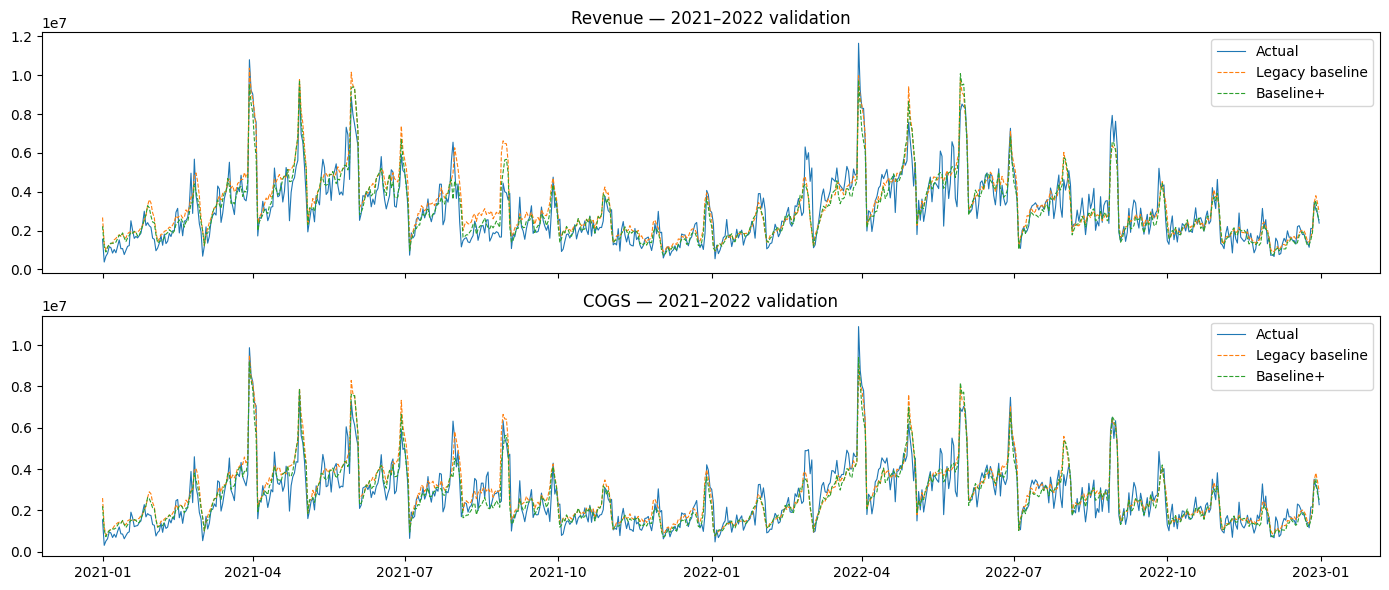

In [18]:
val = cal[cal['year'].isin([2021, 2022])].copy()

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

def smape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(2.0 * np.abs(actual - pred) / (np.abs(actual) + np.abs(pred) + eps)))

score_table = pd.DataFrame([
    {
        'target': 'Revenue',
        'model': 'legacy_baseline',
        'MAPE': mape(val['Revenue'], val['Revenue_pred_legacy']),
        'SMAPE': smape(val['Revenue'], val['Revenue_pred_legacy']),
    },
    {
        'target': 'Revenue',
        'model': 'baseline_plus',
        'MAPE': mape(val['Revenue'], val['Revenue_pred_improved']),
        'SMAPE': smape(val['Revenue'], val['Revenue_pred_improved']),
    },
    {
        'target': 'COGS',
        'model': 'legacy_baseline',
        'MAPE': mape(val['COGS'], val['COGS_pred_legacy']),
        'SMAPE': smape(val['COGS'], val['COGS_pred_legacy']),
    },
    {
        'target': 'COGS',
        'model': 'baseline_plus',
        'MAPE': mape(val['COGS'], val['COGS_pred_improved']),
        'SMAPE': smape(val['COGS'], val['COGS_pred_improved']),
    },
])

score_table = score_table.sort_values(['target', 'SMAPE']).reset_index(drop=True)
display(score_table)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(val['Date'], val['Revenue'], lw=0.8, label='Actual')
axes[0].plot(val['Date'], val['Revenue_pred_legacy'], lw=0.8, linestyle='--', label='Legacy baseline')
axes[0].plot(val['Date'], val['Revenue_pred_improved'], lw=0.8, linestyle='--', label='Baseline+')
axes[0].set_title('Revenue — 2021–2022 validation')
axes[0].legend()

axes[1].plot(val['Date'], val['COGS'], lw=0.8, label='Actual')
axes[1].plot(val['Date'], val['COGS_pred_legacy'], lw=0.8, linestyle='--', label='Legacy baseline')
axes[1].plot(val['Date'], val['COGS_pred_improved'], lw=0.8, linestyle='--', label='Baseline+')
axes[1].set_title('COGS — 2021–2022 validation')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7 — Export Submission (Baseline+)

In [19]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

OUT_DIR.mkdir(parents=True, exist_ok=True)
submission.to_csv(OUT_FILE, index=False)
submission.to_csv(OUT_FILE_CANONICAL, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
print(f'Also updated canonical file: {OUT_FILE_CANONICAL}')
submission.head(10)

Saved 548 rows to ..\data_cleaned\forecast\baseline_plus_submission.csv
Also updated canonical file: ..\data_cleaned\forecast\submission.csv


,Date,Revenue,COGS
0,2023-01-01,2562942.18,2474349.71
1,2023-01-02,1322920.25,1187536.12
2,2023-01-03,974784.34,790800.81
3,2023-01-04,1180098.70,941450.65
4,2023-01-05,1274455.94,1021401.37
5,2023-01-06,1166861.27,946704.98
6,2023-01-07,1185447.41,967980.41
7,2023-01-08,1397883.13,1142153.68
8,2023-01-09,1582729.08,1304044.84
9,2023-01-10,1725469.15,1392372.77


## 8 — Random Forest on Engineered Features
Train on `output/train_features.csv` + `output/train_target.csv`, then predict `output/test_features.csv`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

FEAT_DIR = Path("..") / "output"
TRAIN_FEATURES = FEAT_DIR / "train_features.csv"
TEST_FEATURES = FEAT_DIR / "test_features.csv"
TRAIN_TARGET = FEAT_DIR / "train_target.csv"

if not TRAIN_FEATURES.exists() or not TEST_FEATURES.exists() or not TRAIN_TARGET.exists():
    raise FileNotFoundError("Missing processed feature files. Run scripts/process_data_pipeline.py first.")

train_feat = pd.read_csv(TRAIN_FEATURES, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
test_feat = pd.read_csv(TEST_FEATURES, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
train_target = pd.read_csv(TRAIN_TARGET, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

train = train_feat.merge(train_target, on="Date", how="left")
if train["Revenue"].isna().any() or train["COGS"].isna().any():
    raise ValueError("Target merge failed: missing Revenue/COGS after join on Date.")

X = train.drop(columns=["Date", "Revenue", "COGS"]).copy()
y = train[["Revenue", "COGS"]].copy()

val_days = 180
split_date = train["Date"].max() - pd.Timedelta(days=val_days)
train_mask = train["Date"] <= split_date
val_mask = train["Date"] > split_date

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

median_values = X_train.median(numeric_only=True)
X_train = X_train.fillna(median_values).fillna(0.0)
X_val = X_val.fillna(median_values).fillna(0.0)

try:
    from sklearn.ensemble import RandomForestRegressor
except ImportError as exc:
    raise ImportError("scikit-learn is required. Install with: pip install scikit-learn") from exc

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
    bootstrap=True,
    max_features="sqrt",
)
rf.fit(X_train, y_train)

val_pred = rf.predict(X_val)
val_pred = pd.DataFrame(val_pred, columns=["Revenue", "COGS"])

def mape(actual, pred):
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    eps = 1e-9
    return float(np.mean(np.abs(actual - pred) / (np.abs(actual) + eps)))

print("Validation days:", int(val_mask.sum()))
print("MAPE Revenue:", f"{mape(y_val['Revenue'], val_pred['Revenue']):.4f}")
print("MAPE COGS   :", f"{mape(y_val['COGS'], val_pred['COGS']):.4f}")

X_full = X.fillna(median_values).fillna(0.0)
rf.fit(X_full, y)

X_test = test_feat.drop(columns=["Date"]).copy()
X_test = X_test.fillna(median_values).fillna(0.0)

test_pred = rf.predict(X_test)
test_pred = pd.DataFrame(test_pred, columns=["Revenue", "COGS"])

submission = pd.DataFrame({
    "Date": test_feat["Date"].dt.strftime("%Y-%m-%d"),
    "Revenue": np.maximum(test_pred["Revenue"], 0.0).round(2),
    "COGS": np.maximum(test_pred["COGS"], 0.0).round(2),
})
submission["COGS"] = np.minimum(submission["COGS"], submission["Revenue"] * 0.995)

out_dir = Path("../data_cleaned/forecast")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "random_forest_submission.csv"
submission.to_csv(out_path, index=False)

print("Saved:", out_path)
submission.head(10)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Validation days: 180
MAPE Revenue: 0.2396
MAPE COGS   : 0.2437
Saved: ..\data_cleaned\forecast\random_forest_submission.csv


,Date,Revenue,COGS
0,2023-01-01,2021276.13,1812169.66
1,2023-01-02,1445228.93,1237682.25
2,2023-01-03,1436372.55,1192658.71
3,2023-01-04,1465716.61,1202857.13
4,2023-01-05,1500055.10,1225452.16
5,2023-01-06,1598336.57,1302994.32
6,2023-01-07,1657488.85,1350452.96
7,2023-01-08,1807117.36,1463222.54
8,2023-01-09,1914814.83,1547029.44
9,2023-01-10,1885049.97,1520597.98
